In [80]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io


#self defined function
def clean_sex(i):
    if i == 'M': return 'Male'
    if i == 'F': return 'Female'
    return 'Unknown'

def clean_boro(i):
    if i == 'B': return 'Bronx'
    if i == 'S': return 'Staten Island'
    if i == 'K': return 'Brooklyn'
    if i == 'M': return 'Manhattan'
    if i == 'Q': return 'Queens'


#data source
url = 'https://data.cityofnewyork.us/api/views/uip8-fykc/rows.csv?accessType=DOWNLOAD'
df = pd.read_csv(url)

#exploring data
df.info()
print(df.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278953 entries, 0 to 278952
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ARREST_KEY         278953 non-null  int64  
 1   ARREST_DATE        278953 non-null  object 
 2   PD_CD              278953 non-null  int64  
 3   PD_DESC            278953 non-null  object 
 4   KY_CD              278930 non-null  float64
 5   OFNS_DESC          278953 non-null  object 
 6   LAW_CODE           278953 non-null  object 
 7   LAW_CAT_CD         277479 non-null  object 
 8   ARREST_BORO        278953 non-null  object 
 9   ARREST_PRECINCT    278953 non-null  int64  
 10  JURISDICTION_CODE  278953 non-null  int64  
 11  AGE_GROUP          278953 non-null  object 
 12  PERP_SEX           278953 non-null  object 
 13  PERP_RACE          278953 non-null  object 
 14  X_COORD_CD         278953 non-null  int64  
 15  Y_COORD_CD         278953 non-null  int64  
 16  La

In [81]:
#cleaning data and reassigning name with self_defined function
df['BORO_NAME'] = df['ARREST_BORO'].apply(clean_boro)
df['PERP_SEX'] = df['PERP_SEX'].apply(clean_sex)

# verify data
print(df.head(10))

   ARREST_KEY ARREST_DATE  PD_CD            PD_DESC  KY_CD       OFNS_DESC  \
0   299201470  01/10/2025    105  STRANGULATION 1ST  106.0  FELONY ASSAULT   
1   299351927  01/13/2025    105  STRANGULATION 1ST  106.0  FELONY ASSAULT   
2   299366743  01/13/2025    157             RAPE 1  104.0            RAPE   
3   300990163  02/12/2025    153             RAPE 3  104.0            RAPE   
4   301010124  02/12/2025    157             RAPE 1  104.0            RAPE   
5   301989860  03/03/2025    157             RAPE 1  104.0            RAPE   
6   302130401  03/05/2025    105  STRANGULATION 1ST  106.0  FELONY ASSAULT   
7   302254604  03/08/2025    105  STRANGULATION 1ST  106.0  FELONY ASSAULT   
8   302692601  03/12/2025    105  STRANGULATION 1ST  106.0  FELONY ASSAULT   
9   303343948  03/21/2025    153             RAPE 3  104.0            RAPE   

     LAW_CODE LAW_CAT_CD ARREST_BORO  ARREST_PRECINCT  JURISDICTION_CODE  \
0  PL 1211200          F           Q              110            

In [82]:
# Goal: to compare crime rate by borough and by gender
# for this type of comparison, i need to create table with borough as row and gender as column
# pivot_table()
pivot_df = df.pivot_table(index='BORO_NAME', # define row
                          columns='PERP_SEX', # define column
                          values='ARREST_KEY', # value to calculate
                          aggfunc='count', # calculation method
                          fill_value=0) # fill value with 0 if cannot find combo

print(pivot_df)

PERP_SEX       Female   Male  Unknown
BORO_NAME                            
Bronx            4148  20104    38581
Brooklyn         6400  29240    44242
Manhattan        4823  25412    36213
Queens           5855  27996    24232
Staten Island    1616   6122     3969


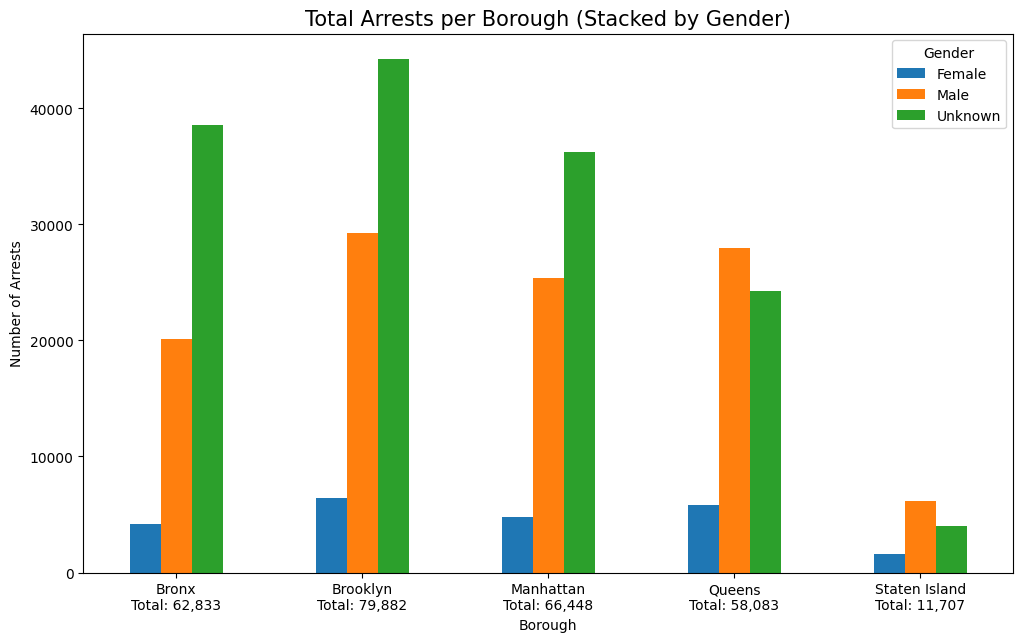

In [83]:
# plot
graph = pivot_df.plot(kind='bar',
                   stacked=False,
                   figsize=(12, 7),
                   )

# calculate totals
total_counts = pivot_df.sum(axis=1)

# create labels with total count below borough name
xlabels = [f"{boro}\nTotal: {int(tot):,}" for boro, tot in total_counts.items()]


plt.title('Total Arrests per Borough (Stacked by Gender)', fontsize=15)
plt.ylabel('Number of Arrests')
# define x label with total count
graph.set_xticks(range(len(xlabels))) # assign label in position
graph.set_xticklabels(xlabels, rotation=0) # define which label in the position
plt.xlabel('Borough')
plt.xticks(rotation=0) # Keeps borough names horizontal
plt.legend(title='Gender')

plt.show()